# Tier 1 — National Screening: Potensi CCS di Cekungan-Cekungan Indonesia

**Status: PROTOTYPE — most data in this notebook are EXAMPLES/PLACEHOLDERS.**

This notebook replicates the *spirit* of two studies:

- **de Jonge-Anderson et al. (2025)** — *Regional screening of saline aquifers in the Malay Basin for CO2 storage*, IJGGC 143 — for the technical workflow (subsurface cut-offs, CO2 thermophysics, clustering, Monte Carlo capacity).
- **Nooraiepour et al. (2025)** — *Geological CO2 storage assessment in emerging CCS regions: ... Poland*, IJGGC 148 — for the strategic framework of an emerging region: **resource-reserve pyramid** and **Storage Readiness Level (SRL)**.

The objective of this notebook (Tier 1) is **not** to produce capacity figures suitable for business/investment decisions — but to build a multi-basin comparison framework similar to **Table 2 in the Poland paper**, as a roadmap toward more in-depth Tier 2 studies (`01_tier2_sunda_asri_workflow.ipynb`).

> ⚠️ **Read this first**: the capacity columns, precise coordinates, and some geological attributes in this notebook use **illustrative data** (`src/fetch_open_data.py --mode sample`), not results from actual digitization/download. See `docs/data_provenance.md` for a list of actual data sources and `docs/methodology.md` for a complete list of limitations.

## 0. Setup

In [ ]:

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False and (Path.cwd().name == "notebooks") else Path.cwd()
# a more robust fallback: look for a folder that contains config.yaml`
_p = Path.cwd()
while not (_p / "config.yaml").exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from load_config import load_config
from emission_source_proximity import nearest_emitter_distance
from montecarlo_capacity import monte_carlo_capacity, summarize_capacity, NormalParam

cfg = load_config(REPO_ROOT / "config.yaml")
pd.set_option("display.max_colwidth", 60)
print("Repo root:", REPO_ROOT)
print("Config termuat, target SRL Tier 1:", cfg["storage_readiness"]["tier1_target_srl"])


Repo root: c:\Users\Arsy Nuur\ccs-screening
Config termuat, target SRL Tier 1: 1


## 1. Load data cekungan & sumber emisi (data CONTOH)

Kalau file sample belum ada, generate dulu lewat `fetch_open_data.py`.


In [20]:
# 1. Definisikan jalur berkas berdasarkan config.yaml
real_basins_path = REPO_ROOT / cfg["paths"]["real"]["basins_processed"]
real_emitters_path = REPO_ROOT / cfg["paths"]["real"]["emitters"]

sample_basins_path = REPO_ROOT / cfg["paths"]["sample"]["basins"]
sample_emitters_path = REPO_ROOT / cfg["paths"]["sample"]["emitters"]

print("=== STATUS DETEKSI DATA SINKRONISASI ===")

# 2. Cek dan tentukan data BASINS secara mandiri
if real_basins_path.exists():
    basins_path = real_basins_path
    print("✅ BASINS: Menggunakan DATA RIIL (basins_processed.csv)")
else:
    basins_path = sample_basins_path
    print("ℹ️  BASINS: Data riil belum ada. Fallback ke DATA CONTOH (sample_basins_indonesia.csv)")

# 3. Cek dan tentukan data EMITTERS secara mandiri
if real_emitters_path.exists():
    emitters_path = real_emitters_path
    print("✅ EMITTERS: Menggunakan DATA RIIL (indonesia_emitters_riil.csv)")
else:
    emitters_path = sample_emitters_path
    print("ℹ️  EMITTERS: Data riil belum ada. Fallback ke DATA CONTOH (sample_emitters_indonesia.csv)")

print("=======================================\n")

# 4. Tentukan subfolder output secara otomatis untuk memisahkan hasil Git agar tidak bocor
global output_subfolder
output_subfolder = "real" if (real_basins_path.exists() or real_emitters_path.exists()) else "sample"

# 5. Memuat berkas ke dalam Pandas DataFrame
basins = pd.read_csv(basins_path)
emitters = pd.read_csv(emitters_path)

# 6. Otomatis penyelarasan nama kolom & pembuatan label dummy untuk mencegah KeyError kolom data riil
emitter_rename_map = {
    "Latitude": "lat",
    "Longitude": "lon",
    "annual_co2_mtpa": "capacity_mtpa_co2_est"
}
emitters = emitters.rename(columns=emitter_rename_map)

# Jembatan otomatis: Jika data riil tidak punya kolom 'name' & 'sector' bawaan, buatkan instan untuk peta
if "name" not in emitters.columns:
    emitters["name"] = emitters["Country"] + " Source #" + emitters.index.astype(str)
if "sector" not in emitters.columns:
    emitters["sector"] = "CO2 Industrial Emitter"

# Penyelarasan nama kolom untuk basins jika menggunakan data riil
basins = basins.rename(columns={"Latitude": "lat", "Longitude": "lon"})
if "srl_placeholder" not in basins.columns:
    basins["srl_placeholder"] = 1

print(f"Sukses memuat {len(basins)} data cekungan dan {len(emitters)} titik emisi.")

=== STATUS DETEKSI DATA SINKRONISASI ===
ℹ️  BASINS: Data riil belum ada. Fallback ke DATA CONTOH (sample_basins_indonesia.csv)
✅ EMITTERS: Menggunakan DATA RIIL (indonesia_emitters_riil.csv)

Sukses memuat 8 data cekungan dan 1565 titik emisi.


## 2. Kerangka Storage Readiness Level (SRL) per cekungan

Mengikuti definisi SRL di Poland paper (Akhurst et al., 2019, diadaptasi):

| SRL | Deskripsi |
|---|---|
| 1 | First-pass, basin/country-scale assessment memakai data geologi yang sudah ada |
| 2 | Site dengan kapasitas teoretis dipetakan sistematis |
| 3 | Screening study detail per-site + konsep proyek awal |

Semua 8 cekungan contoh di notebook ini kita tempatkan di **SRL 1** — itu jujur
mengingat kita cuma pakai data publik tingkat basin, belum ada data sumur.


In [21]:

srl_labels = {1: "SRL 1 - basin-scale, data publik", 2: "SRL 2 - kapasitas dipetakan sistematis", 3: "SRL 3 - screening detail per-site"}
basins["srl_label"] = basins["srl_placeholder"].map(srl_labels)
basins[["basin", "srl_placeholder", "srl_label", "ccs_policy_priority"]]


,basin,srl_placeholder,srl_label,ccs_policy_priority
0,Sunda-Asri Basin,1,"SRL 1 - basin-scale, data publik",True
1,South Sumatra Basin,1,"SRL 1 - basin-scale, data publik",True
2,North Sumatra Basin,1,"SRL 1 - basin-scale, data publik",False
3,Northwest Java Basin,1,"SRL 1 - basin-scale, data publik",False
4,East Java Basin,1,"SRL 1 - basin-scale, data publik",False
5,Kutai Basin,1,"SRL 1 - basin-scale, data publik",False
6,Bintuni Basin,1,"SRL 1 - basin-scale, data publik",True
7,"Malay Basin (Natuna, sisi Indonesia)",1,"SRL 1 - basin-scale, data publik",False


## 3. Proximity ke sumber emisi CO2

Menghitung jarak great-circle dari centroid tiap cekungan ke emitter
terdekat (analog analisis Fig. 7 di Poland paper: *"spatial analysis
illustrates proximity relationships between emission sources and
sequestration opportunities"*). Data emitter di sini sintetik — ganti
dengan Global Energy Monitor tracker asli untuk hasil yang bisa dipakai
serius.


In [22]:

basins_with_proximity = nearest_emitter_distance(
    basins, emitters,
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    emitter_capacity_col="capacity_mtpa_co2_est",
)
cols = ["basin", "nearest_emitter_name", "nearest_emitter_km", "nearest_emitter_capacity"]
basins_with_proximity[cols].sort_values("nearest_emitter_km")


,basin,nearest_emitter_name,nearest_emitter_km,nearest_emitter_capacity
4,East Java Basin,Indonesia Source #625,15.406532,2.500000
1,South Sumatra Basin,Indonesia Source #634,20.222279,0.620000
3,Northwest Java Basin,Indonesia Source #221,31.526236,1.958919
5,Kutai Basin,Indonesia Source #47,39.555140,1.800000
0,Sunda-Asri Basin,Indonesia Source #228,47.740675,0.000000
2,North Sumatra Basin,Indonesia Source #533,89.678936,0.000000
6,Bintuni Basin,Indonesia Source #0,156.105089,0.900000
7,"Malay Basin (Natuna, sisi Indonesia)",Indonesia Source #267,351.013311,0.586995


## 4. Ilustrasi resource-reserve pyramid (Tier reduction)

Demonstrasi konsep **theoretical -> effective capacity** (Poland paper,
Fig. 3 & Eq. 1-2) dengan Monte Carlo, memakai **geometri ilustratif**
(bukan hasil digitasi asli) untuk tiap cekungan. Efficiency factor E
untuk saline aquifer di-set 1-2% sesuai rentang umum di literatur (Poland
& Malay Basin paper).

> Ini murni untuk menunjukkan *bentuk* distribusi P10/P50/P90 — jangan
> baca angka absolutnya sebagai estimasi nyata.


In [23]:

rng = np.random.default_rng(42)
illustrative_results = []

for _, row in basins.iterrows():
    # geometri ilustratif skala-basin (BUKAN dari digitasi asli)
    area_km2 = rng.uniform(3_000, 25_000)
    mc = monte_carlo_capacity(
        area_km2=area_km2,
        thickness_m=NormalParam(mean=rng.uniform(150, 500), std=100, lower_bound=0),
        ntg_fraction=NormalParam(mean=rng.uniform(0.15, 0.4), std=0.1, lower_bound=0, upper_bound=1),
        porosity_fraction=NormalParam(mean=rng.uniform(0.15, 0.28), std=0.04, lower_bound=0, upper_bound=1),
        swirr_fraction=NormalParam(
            mean=cfg["capacity_equation"]["swirr_mean"],
            std=cfg["capacity_equation"]["swirr_std"],
            lower_bound=0, upper_bound=1,
        ),
        efficiency_fraction=NormalParam(
            mean=cfg["capacity_equation"]["efficiency_factor_percent_mean"] / 100,
            std=cfg["capacity_equation"]["efficiency_factor_percent_std"] / 100,
            lower_bound=0, upper_bound=1,
        ),
        co2_density_kgm3=NormalParam(mean=rng.uniform(300, 450), std=40, lower_bound=0),
        n_iterations=cfg["capacity_equation"]["monte_carlo_iterations"],
        random_seed=int(rng.integers(0, 10_000)),
    )
    stats = summarize_capacity(mc)
    stats["basin"] = row["basin"]
    stats["illustrative_area_km2"] = area_km2
    illustrative_results.append(stats)

illustrative_df = pd.DataFrame(illustrative_results).set_index("basin")
illustrative_df = illustrative_df[["illustrative_area_km2", "P10_Gt", "P50_Gt", "P90_Gt", "mean_Gt", "std_Gt"]]
illustrative_df.round(2)


,illustrative_area_km2,P10_Gt,P50_Gt,P90_Gt,mean_Gt,std_Gt
basin,,,,,,
Sunda-Asri Basin,20027.03,3.99,2.06,0.84,2.32,1.34
South Sumatra Basin,19745.07,3.10,1.34,0.30,1.58,1.20
North Sumatra Basin,23388.83,5.38,2.90,1.38,3.22,1.67
Northwest Java Basin,4403.98,1.28,0.67,0.30,0.74,0.41
East Java Basin,24355.36,5.98,3.25,1.52,3.55,1.87
Kutai Basin,6394.37,2.07,1.09,0.49,1.19,0.63
Bintuni Basin,11150.11,1.15,0.51,0.16,0.60,0.42
"Malay Basin (Natuna, sisi Indonesia)",17735.91,3.84,2.08,0.98,2.31,1.27


## 5. Visualisasi ringkasan (gaya Table 2 / Fig. 7 Poland paper)

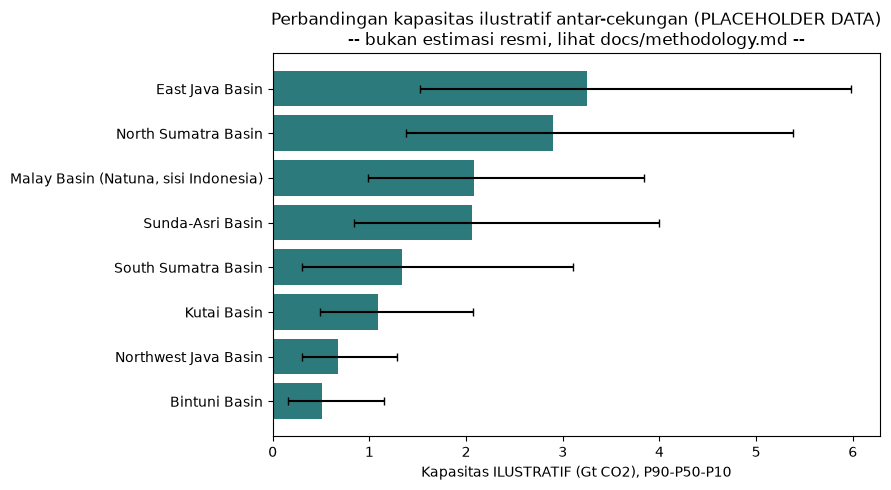

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = illustrative_df.sort_values("P50_Gt", ascending=True)
ax.barh(plot_df.index, plot_df["P50_Gt"], color="#2c7a7b")
ax.errorbar(
    plot_df["P50_Gt"], plot_df.index,
    xerr=[plot_df["P50_Gt"] - plot_df["P90_Gt"], plot_df["P10_Gt"] - plot_df["P50_Gt"]],
    fmt="none", ecolor="black", capsize=3,
)
ax.set_xlabel("Kapasitas ILUSTRATIF (Gt CO2), P90-P50-P10")
ax.set_title("Perbandingan kapasitas ilustratif antar-cekungan (PLACEHOLDER DATA)\n"
              "-- bukan estimasi resmi, lihat docs/methodology.md --")
plt.tight_layout()

# Tentukan folder output gambar berdasarkan jenis data yang aktif (dibuat otomatis jika belum ada)
figures_dir = REPO_ROOT / "figures" / output_subfolder
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(figures_dir / "tier1_illustrative_capacity_comparison.png", dpi=150)
plt.show()

In [25]:
try:
    import folium

    m = folium.Map(location=[-2.5, 113], zoom_start=5, tiles="cartodbpositron")

    for _, row in basins.iterrows():
        color = "crimson" if row["ccs_policy_priority"] else "steelblue"
        note_text = row["note"] if "note" in basins.columns else "No description available"
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=9,
            color=color,
            fill=True,
            fill_opacity=0.85,
            popup=f"<b>{row['basin']}</b><br>{row['region']}<br>{note_text}",
        ).add_to(m)

    for _, row in emitters.iterrows():
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=3,
            color="gray",
            fill=True,
            fill_opacity=0.5,
            popup=f"{row['name']} ({row['sector']})",
        ).add_to(m)

    # Sesuaikan teks legenda peta berdasarkan asal data emisi aktif
    emitter_label = "Sumber emisi RIIL (indonesia_emitters_riil.csv)" if output_subfolder == "real" else "Sumber emisi (CONTOH/SYNTHETIC)"

    legend_html = (
        f'<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; '
        f'background: white; padding: 10px; border: 1px solid #999; font-size: 13px;">'
        f'<b>Legenda</b><br>'
        f'<span style="color:crimson;">&#9679;</span> Cekungan prioritas CCS (kebijakan resmi)<br>'
        f'<span style="color:steelblue;">&#9679;</span> Cekungan lain<br>'
        f'<span style="color:gray;">&#9679;</span> {emitter_label}'
        f'</div>'
    )
    m.get_root().html.add_child(folium.Element(legend_html))

    # Tentukan folder output berkas peta HTML berdasarkan jenis data yang aktif
    figures_dir = REPO_ROOT / "figures" / output_subfolder
    figures_dir.mkdir(parents=True, exist_ok=True)

    map_path = figures_dir / "tier1_indonesia_basins_map.html"
    m.save(str(map_path))
    print("Peta interaktif disimpan ke:", map_path)
    m
except ImportError:
    print("folium belum terinstall - lewati visualisasi peta.")

Peta interaktif disimpan ke: c:\Users\Arsy Nuur\ccs-screening\figures\real\tier1_indonesia_basins_map.html


## 6. Ringkasan & langkah berikutnya

**Yang sudah didemokan di notebook ini:**
1. Kerangka SRL per cekungan (gaya Poland paper §3.2)
2. Analisis proximity cekungan <-> emitter (gaya Poland paper Fig. 7)
3. Contoh alur resource-reserve pyramid dengan Monte Carlo (gaya Poland Eq. 1-2
   & Malay Basin Eq. 2), memakai geometri ilustratif

**Yang BELUM dilakukan (limitasi jujur untuk prototipe ini):**
- Boundary cekungan asli (masih titik centroid kasar, bukan poligon dari
  digitasi peta Badan Geologi)
- Data emitter asli dari Global Energy Monitor (masih sintetik)
- Geothermal gradient & porosity-depth trend lokal Indonesia (masih pakai
  proxy generik di `config.yaml`)

**Langkah berikutnya**: `01_tier2_sunda_asri_workflow.ipynb` — replikasi
penuh workflow grid depth/temperature/pressure -> CO2 thermophysics ->
cut-off -> DBSCAN -> Monte Carlo untuk Cekungan Sunda-Asri secara spesifik,
begitu data digitasi tersedia (lihat `docs/data_provenance.md` untuk
checklist unduhan).
